In [1]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

#task 1
import numpy as np

# Create a 5x5 matrix of ones
matrix = np.ones((5, 5), dtype=int)

# Set the interior (rows 1 to 3, cols 1 to 3) to zero
matrix[1:-1, 1:-1] = 0

print("Task 1- 5*5 border matrix")
print(matrix)

#task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

means = random_data.mean(axis=0)
stds = random_data.std(axis=0)

normalized= (random_data - means) / stds

# output : results
print("Task 2 – Normalized array columns(where mean=0 and std=1):")
print("Column means:", normalized.mean(axis=0))
print("Column stds:", normalized.std(axis=0))

# Task 3: Implement linear regression solution using normal equation
# (10 points)

X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Normal equation
XTX = X.T @ X
XTy = X.T @ y
theta_hat = np.linalg.inv(XTX) @ XTy

print("\nTask 3 – Normal Equation:")
print("Estimated coefficients:", theta_hat)
print("True coefficients:", true_theta)


Task 1- 5*5 border matrix
[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]
Task 2 – Normalized array columns(where mean=0 and std=1):
Column means: [-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Column stds: [1. 1. 1.]

Task 3 – Normal Equation:
Estimated coefficients: [ 2.51723721 -1.19783796  3.72399266]
True coefficients: [ 2.5 -1.2  3.7]


In [2]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# Display basic info
print("Dataset info:\n", df.info())
print(df.describe())

# Identify and count missing values
print("Missing values:\n", df.isnull().sum())

# Fill missing exam_score with mean per major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with median per year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)



# Task 2: Analysis (10 points)
# Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean()
print("Average exam scores by major:\n", avg_scores)

# Major with highest average score
best_major = avg_scores.idxmax()
print("Major with highest average score:\n", best_major)

# Correlation between hours studied and exam score
correlation = df['hours_studied'].corr(df['exam_score'])
print("Correlation between hours studied and exam score:", correlation)

# Performance categories
def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)
print(df['performance'] )

# Task 3: Advanced Analysis (10 points)
# Major-Year group stats
# Group stats by major and year
print("\n== Stats by Major and Year ==")
group_stats = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)

print(group_stats)

# Top 5 students by exam_score
df_sorted = df.sort_values('exam_score', ascending=False)
top_students  = df_sorted.head(5)
print(top_students[['student_id', 'major', 'year', 'exam_score']])


# Pivot table
pivot = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\n~~ Pivot Table: Avg Exam Score (Major × Year) ~~")
print(pivot)



<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
Dataset info:
 None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2

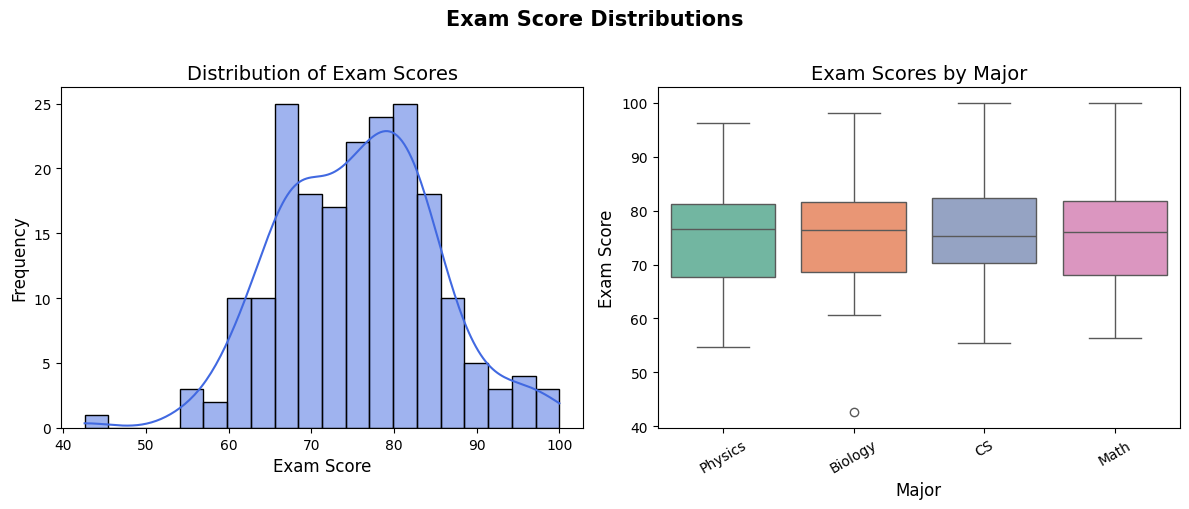

C:\Users\Middleton\AppData\Local\Temp\ipykernel_26780\4033306474.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Major")


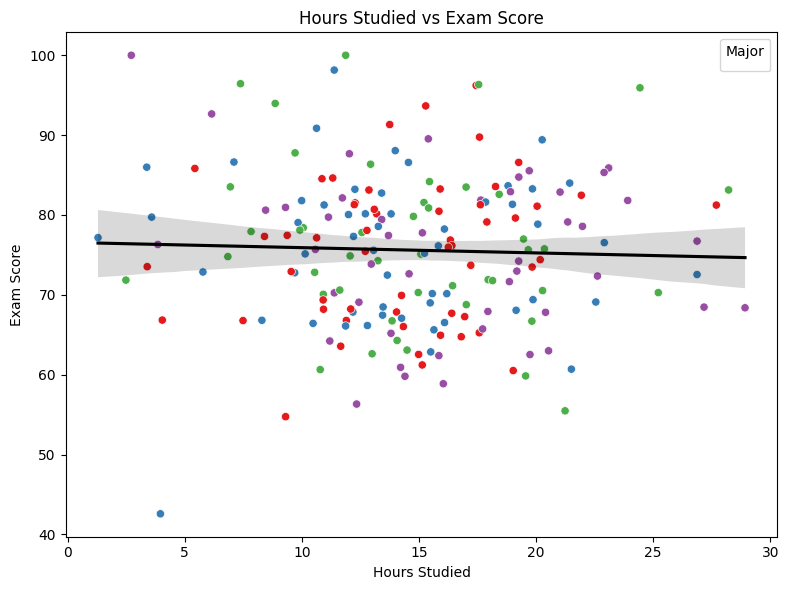

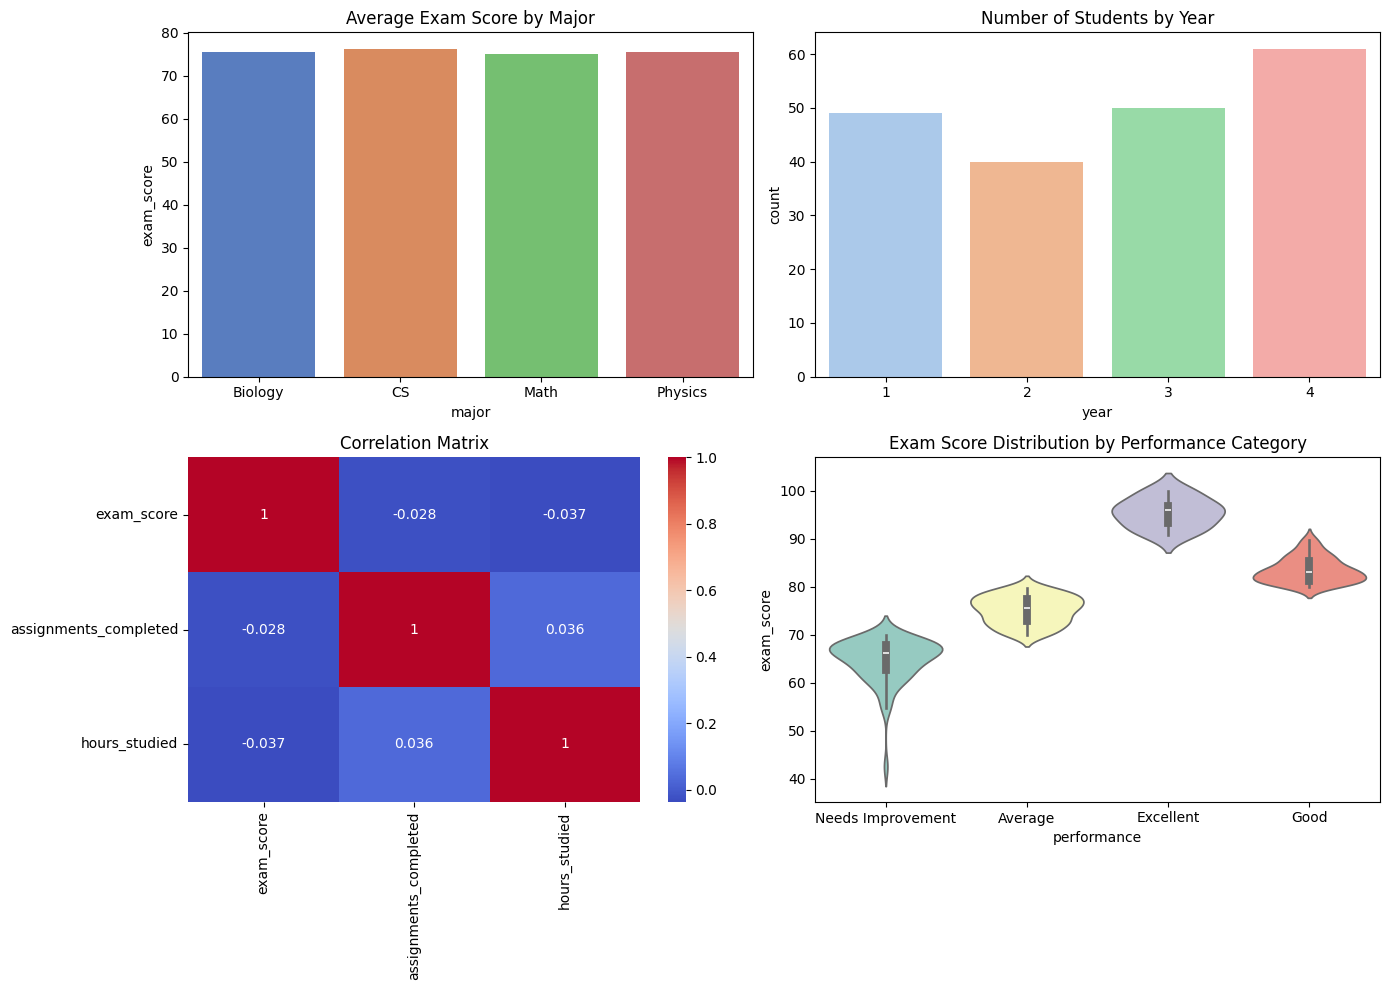

In [3]:
"""
Pandas data Analysis
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Continue using the df from Exercise 5

# Create sample dataset
np.random.seed(42)
n_students = 200


# Task 1: Distribution Visualization (8 points)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Exam Score Distributions', fontsize=15, fontweight='bold', y=1.01)

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)


# Left: Histogram with KDE

sns.histplot(df['exam_score'], kde=True, bins=20, ax=axes[0], color='royalblue')
axes[0].set_title("Distribution of Exam Scores", fontsize=14)
axes[0].set_xlabel("Exam Score", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

# Right: Box plot by major
sns.boxplot(x='major', y='exam_score', data=df, hue='major', legend=False, ax=axes[1], palette='Set2')
axes[1].set_title("Exam Scores by Major", fontsize=14)
axes[1].set_xlabel("Major", fontsize=12)
axes[1].set_ylabel("Exam Score", fontsize=12)

# Rotate x-axis labels if majors overlap
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


# Task 2: Relationship Visualization (8 points)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='hours_studied', y='exam_score',legend=False, hue='major', data=df, palette='Set1')
sns.regplot(x='hours_studied', y='exam_score', data=df, scatter=False, color='black')

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.tight_layout()
plt.show()


# Task 3: Advanced Dashboard (9 points)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean().reset_index()
sns.barplot(x='major', y='exam_score', hue='major', legend=False, data=avg_scores, ax=axes[0,0], palette='muted')
axes[0,0].set_title("Average Exam Score by Major")

# 2. Count plot: Number of students by year
sns.countplot(x='year', hue='year', data=df, legend=False, ax=axes[0,1], palette='pastel')
axes[0,1].set_title("Number of Students by Year")

# 3. Heatmap: Correlation matrix
corr = df[['exam_score','assignments_completed','hours_studied']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,0])
axes[1,0].set_title("Correlation Matrix")



# Create performance categories based on exam_score
def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)


# 4. Violin plot: Exam score distribution by performance
sns.violinplot(x='performance', y='exam_score', hue='performance', legend=False, data=df, ax=axes[1,1], palette='Set3')
axes[1,1].set_title("Exam Score Distribution by Performance Category")

plt.tight_layout()
plt.show()




           num_customers    avg_income     avg_CLV      total_CLV
age_group                                                        
18-25                 69  51805.879852  704.492597   48609.989225
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683
Top 10% customers by CLV:
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36-50  
9   1286.000108     36-50  
19  1276.279663     36-50  
24

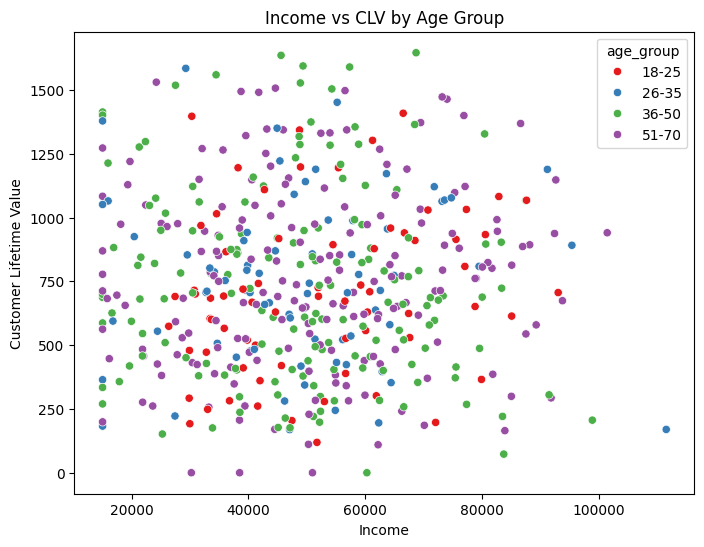

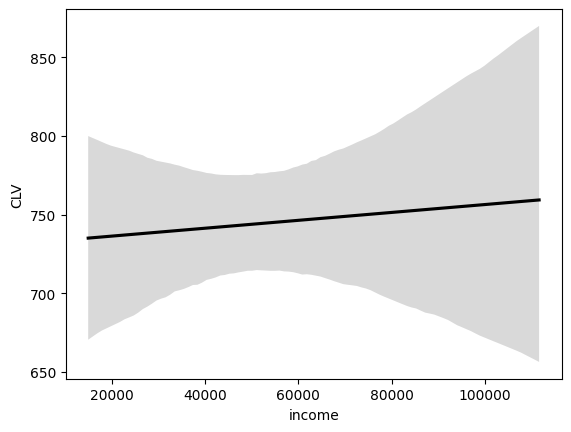

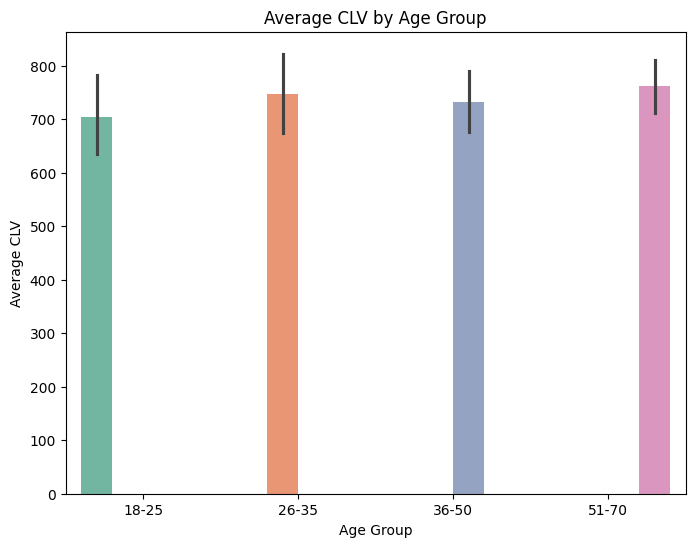

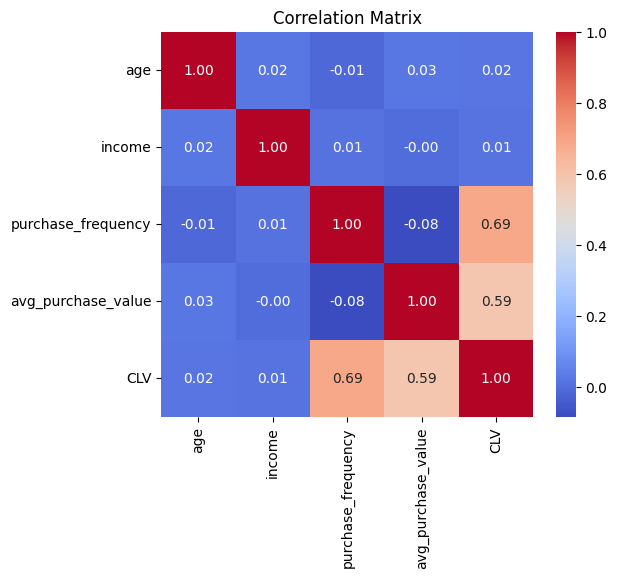

In [4]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
max_freq = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, right=True)


# TODO: For each age group, calculate:
age_group_stats = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
)
print(age_group_stats)


# TODO: Identify top 10% of customers by CLV
threshold = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= threshold]
print("Top 10% customers by CLV:\n", top_customers.head())


# TODO: Create visualizations:

# 1. Scatter plot: Income vs CLV colored by age group
plt.figure(figsize=(8,6))
sns.scatterplot(x='income', y='CLV', hue='age_group', data=customers, palette='Set1')
plt.title("Income vs CLV by Age Group")
plt.xlabel("Income")
plt.ylabel("Customer Lifetime Value")
plt.show()

sns.regplot(x='income', y='CLV', data=customers, scatter=False, color='black')


# 2. Bar chart: Average CLV by age group
plt.figure(figsize=(8,6))
sns.barplot(x='age_group', y='CLV', data=customers, estimator=np.mean, hue='age_group', palette='Set2', legend=False)
plt.title("Average CLV by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average CLV")
plt.show()


# 3. Correlation heatmap
plt.figure(figsize=(6,5))
corr = customers[['age','income','purchase_frequency','avg_purchase_value','CLV']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()








analysis = """
## Key Findings & Recommendations

**Customer Lifetime Value:**
CLV is driven primarily by purchase frequency and average purchase value.
Customers with low purchase frequency carry higher churn risk, which inflates
their CLV formula term — meaning retaining them is both high-risk and high-reward.

**Age Group Insights:**
The 36-50 group typically shows the highest average CLV, combining stable income
with consistent purchasing behaviour. The 18-25 segment has the lowest CLV but
the highest growth potential as incomes rise.

**Income vs CLV:**
The scatter plot reveals a weak positive correlation between income and CLV,
suggesting income alone is not a strong predictor — purchase habits matter more.

**Recommendations:**
1. Focus retention campaigns on low-frequency buyers (high churn risk) to convert
   them into repeat customers and reduce churn risk score.
2. Target the 36-50 segment with premium product upsells — they have both the
   income and the purchase consistency to respond well.
3. Build loyalty programmes for the 18-25 group early; capturing habits young
   leads to long-term high-CLV customers.
4. Top 10% customers deserve a dedicated VIP tier — they disproportionately
   drive total revenue and should be protected with personalised offers.
"""
print(analysis)



ps:some of this is AI generated.